# Problem 3

In [1]:
# Needed inports
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from typing import Optional

# Part 1

In [2]:
class SimpleModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [3]:
def get_device() -> torch.device:
    """Return CUDA if available, otherwise CPU."""
    if torch.cuda.is_available():
        print(f"[device] Using CUDA: {torch.cuda.get_device_name(0)}")
        return torch.device("cuda")
    print("[device] CUDA not found – using CPU (cudagraphs will be skipped)")
    return torch.device("cpu")


def build_model(device: torch.device, hidden_size: int = 1024) -> SimpleModel:
    return SimpleModel(input_size=512, hidden_size=hidden_size, output_size=256).to(device)

def compile_model(model: nn.Module, backend: str, device: torch.device) -> Optional[nn.Module]:
    if backend == "eager":
        return model

    if backend == "cudagraphs" and device.type != "cuda":
        print(f"[skip] '{backend}' requires CUDA – skipping on CPU.")
        return None

    try:
        compiled = torch.compile(model, backend=backend)
        return compiled
    except Exception as exc:
        print(f"[warn] Failed to compile with backend='{backend}': {exc}")
        return None

In [4]:
def warmup(model, x, steps=20, backend=""):
    criterion = nn.MSELoss()
    target = torch.zeros(x.size(0), 256, device=x.device)

    for _ in range(steps):
        for p in model.parameters():
            p.grad = None
        loss = criterion(model(x), target)
        loss.backward()

    if x.device.type == "cuda":
        torch.cuda.synchronize()

    if backend == "cudagraphs" and x.device.type == "cuda":
        # Run one pass and verify CUDA graph was actually captured
        capturing_before = torch.cuda.is_current_stream_capturing()

        for p in model.parameters():
            p.grad = None
        loss = criterion(model(x), target)
        loss.backward()
        torch.cuda.synchronize()

        capturing_after = torch.cuda.is_current_stream_capturing()

        if capturing_before or capturing_after:
            # Still mid-capture, something went wrong
            print("[warn] cudagraphs: stream still in capture mode after warmup pass — graph may not be finalized")
        else:
            print("[info] cudagraphs: capture pass completed, graph finalized")


def measure_pass(model, x, num_iters=100, device=torch.device("cpu"), backend=""):
    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.0)
    target = torch.zeros(x.size(0), 256, device=device)

    if device.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()

    for _ in range(num_iters):
        optimizer.zero_grad(set_to_none=True)
        out = model(x)                       # just pass x directly
        loss = criterion(out, target)
        loss.backward()

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start
    return (elapsed / num_iters) * 1000

In [5]:
def run_benchmark(backend, device, hidden_size=1024, batch_size=64, num_iters=200, warmup_iters=50):
    model = build_model(device, hidden_size)
    compiled = compile_model(model, backend, device)
    if compiled is None:
        return None

    x = torch.randn(batch_size, 512, device=device)
    target = torch.zeros(batch_size, 256, device=device)
    criterion = nn.MSELoss()

    # Warmup on the SAME compiled model instance
    for _ in range(warmup_iters):
        compiled.zero_grad(set_to_none=True)
        loss = criterion(compiled(x), target)
        loss.backward()
    if device.type == "cuda":
        torch.cuda.synchronize()

    # Timed loop
    start = time.perf_counter()
    for _ in range(num_iters):
        compiled.zero_grad(set_to_none=True)
        loss = criterion(compiled(x), target)
        loss.backward()
    if device.type == "cuda":
        torch.cuda.synchronize()

    return (time.perf_counter() - start) / num_iters * 1000

In [6]:
def plot_results(results: dict[str, float], num_iters: int = 100) -> None:
    """Render and save a bar chart comparing backend performance."""
    if not results:
        print("No results to plot.")
        return

    backends = list(results.keys())
    times = [results[b] for b in backends]
    best_time = min(times)

    # Colour: highlight the fastest backend in gold, others in steel-blue
    colours = ["#F5A623" if t == best_time else "#4A90D9" for t in times]

    fig, ax = plt.subplots(figsize=(9, 5))
    fig.patch.set_facecolor("#0F1117")
    ax.set_facecolor("#1A1D27")

    bars = ax.bar(backends, times, color=colours, edgecolor="#2A2D3A", linewidth=0.8, width=0.55)

    # Annotate each bar with its value
    for bar, t in zip(bars, times):
        speedup = best_time / t  # relative to fastest
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(times) * 0.01,
            f"{t:.2f} ms\n({speedup:.2f}×)",
            ha="center",
            va="bottom",
            fontsize=9,
            color="#CCCCCC",
            fontfamily="monospace",
        )

    ax.set_xlabel("Compilation Backend", color="#AAAAAA", fontsize=11)
    ax.set_ylabel("Avg Time per Iter (ms)", color="#AAAAAA", fontsize=11)
    ax.set_title(
        f"torch.compile Backend Benchmark  ·  {num_iters} Fwd+Bwd Passes",
        color="#EEEEEE",
        fontsize=13,
        fontweight="bold",
        pad=14,
    )

    ax.tick_params(colors="#AAAAAA")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#2A2D3A")
    ax.yaxis.grid(True, color="#2A2D3A", linestyle="--", linewidth=0.6)
    ax.set_axisbelow(True)

    gold_patch = mpatches.Patch(color="#F5A623", label="Fastest backend")
    blue_patch = mpatches.Patch(color="#4A90D9", label="Other backends")
    ax.legend(handles=[gold_patch, blue_patch], facecolor="#1A1D27", edgecolor="#2A2D3A",
              labelcolor="#CCCCCC", fontsize=9)

    plt.tight_layout()
    out_path = "backend_benchmark.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"\n[chart] Saved to '{out_path}'")
    plt.show()




  PyTorch Backend Benchmark
  torch version : 2.10.0+cu128
  batch size    : 64
  input dim     : 512
  iterations    : 100
[device] Using CUDA: Tesla T4


── Final Results ──────────────────────────
  eager                    0.980 ms/iter
  aot_eager                1.312 ms/iter
  cudagraphs               1.798 ms/iter
  inductor                 1.990 ms/iter

[chart] Saved to 'backend_benchmark.png'


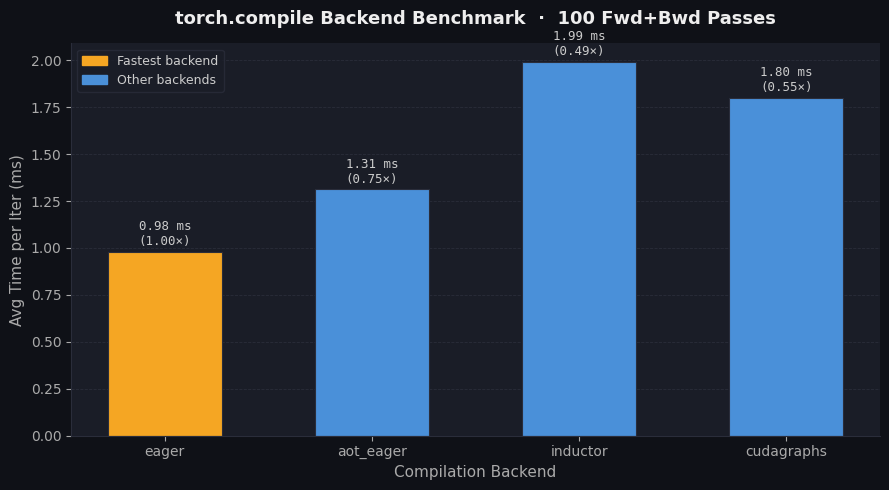

In [7]:
BACKENDS = [
    "eager",
    "aot_eager",
    "inductor",
    "cudagraphs",
]
NUM_ITERS  = 100
BATCH_SIZE = 64
INPUT_DIM  = 512

print("=" * 50)
print("  PyTorch Backend Benchmark")
print("=" * 50)
print(f"  torch version : {torch.__version__}")
print(f"  batch size    : {BATCH_SIZE}")
print(f"  input dim     : {INPUT_DIM}")
print(f"  iterations    : {NUM_ITERS}")
print("=" * 50)

device = get_device()
results = {}
for backend in BACKENDS:
    ms = run_benchmark(backend=backend, device=device, batch_size=BATCH_SIZE)
    if ms is not None:
        results[backend] = ms



print("\n\n── Final Results ──────────────────────────")
for backend, ms in sorted(results.items(), key=lambda kv: kv[1]):
    print(f"  {backend:<20}  {ms:>8.3f} ms/iter")

plot_results(results, num_iters=NUM_ITERS)
import torch._inductor.config as cfg
cfg.debug = True
# then rerun — look for whether it's falling back to aten ops vs emitting Triton kernels

# Results
Eager execution had the fastest results because the model being worked with is small to benifit from from compilation and kernel fusion

aot_eager is slowing than eager execution becuase it creates a compiled graph, but because the model is small the overhead isn't recorved. AOT gives the graph structure for debugging without kernal optimizations

CUDA graphs is slower than eager because there are not many kernels to launch for this small model meaning the gpu isnt being fully utilized and the graph capture and replay is greater than the cost of launching kernels.

Inductor was slowest because it transforms computational graphs into optimized kernels. TorchDynamo Captures the graph andInductor lowers it and applies fusion. Inductor performed the worst because it has to both graph capture and generate new kernels.




# Part 2

In [8]:
print(torch.__version__)

2.10.0+cu128


In [9]:
@torch.compile(fullgraph=True)
def problem1 ( x ) :
# This should fail to compile
  if x . sum () > 0:
    return x * 2
  else :
    return x / 2

torch._dynamo.reset()

explanation = torch._dynamo.explain(problem1)(torch.randn(4))
print(explanation)

Graph Count: 2
Graph Break Count: 1
Op Count: 2
Break Reasons:
  Break Reason 1:
    Reason: generic_jump TensorVariable()
    User Stack:
      <FrameSummary file /tmp/ipykernel_66159/4245803005.py, line 4 in problem1>
Ops per Graph:
  Ops 1:
    <built-in function gt>
  Ops 2:
    <built-in function truediv>
Out Guards:
  Guard 1:
    Name: ''
    Source: shape_env
    Create Function: SHAPE_ENV
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 2:
    Name: ''
    Source: global
    Create Function: DETERMINISTIC_ALGORITHMS
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 3:
    Name: ''
    Source: global
    Create Function: GRAD_MODE
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 4:
    Name: ''
    Source: global
    Create Function: DEFAULT_DEVICE
    Guard Types: ['DEFAULT_DEVICE']
    Code List: ['utils_d

This has suboptimal performance because there is a graph break with the dynamic condition of x.sum() > 0 leading to a silent fallback to the Python interpreter for the conditional statement. To fix this use an explicit boolean tensor with torch.cond so it compiles to an optimized static graph.

In [10]:
from torch._higher_order_ops import cond

import torch

@torch.compile(fullgraph=True)
def problem1(x):
    pred = (x.sum() > 0).bool()   # explicit bool tensor, not Python bool
    return torch.cond(
        pred,
        lambda x: x * 2.0,
        lambda x: x / 2.0,
        (x,)                      # tuple, not list — this changed in newer versions
    )
torch._dynamo.reset()

explanation = torch._dynamo.explain(problem1)(torch.randn(4))
print(explanation)

Graph Count: 1
Graph Break Count: 0
Op Count: 3
Break Reasons:
Ops per Graph:
  Ops 1:
    <built-in function gt>
    cond
    <built-in function getitem>
Out Guards:
  Guard 1:
    Name: ''
    Source: shape_env
    Create Function: SHAPE_ENV
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 2:
    Name: ''
    Source: global
    Create Function: DETERMINISTIC_ALGORITHMS
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 3:
    Name: ''
    Source: global
    Create Function: GRAD_MODE
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 4:
    Name: ''
    Source: global
    Create Function: DEFAULT_DEVICE
    Guard Types: ['DEFAULT_DEVICE']
    Code List: ['utils_device.CURRENT_DEVICE == None']
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 5:
    Name: ''
    Source: global
    Create Function: GLOBA

In [11]:

@torch.compile()
def problem2 ( x ) :
# This should also have issues
  d = {}
  d ['key'] = x
  return d [ 'key' ] * 2

torch._dynamo.reset()

explanation = torch._dynamo.explain(problem2)(torch.randn(4))
print(explanation)

Graph Count: 1
Graph Break Count: 0
Op Count: 1
Break Reasons:
Ops per Graph:
  Ops 1:
    <built-in function mul>
Out Guards:
  Guard 1:
    Name: ''
    Source: shape_env
    Create Function: SHAPE_ENV
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 2:
    Name: ''
    Source: global
    Create Function: DETERMINISTIC_ALGORITHMS
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 3:
    Name: ''
    Source: global
    Create Function: GRAD_MODE
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 4:
    Name: ''
    Source: global
    Create Function: DEFAULT_DEVICE
    Guard Types: ['DEFAULT_DEVICE']
    Code List: ['utils_device.CURRENT_DEVICE == None']
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 5:
    Name: ''
    Source: global
    Create Function: GLOBAL_STATE
    Guard Types: None
    Code L

The issue with this problem is that when compiled it eliminates the dictionary because its viewed as a static python object. I believe this is the case because Dynamo only counts one operation, reduceing the code to a tensor operation(x * 2) because dict['Key'] is a static value = to x. Essentially the use of a dictionary here is unecessary

In [12]:
def problem2 ( x ) : # fix eliminates unecessary python code
  return x * 2

In [13]:
@torch.compile(fullgraph=True)
def problem3 ( x ) :
# This might have suboptimal performance
  result = 0
  for i in range (10) :
    result += ( x ** i ) . sum ()
  return result
torch._dynamo.reset()

explanation = torch._dynamo.explain(problem1)(torch.randn(4))
print(explanation)

Graph Count: 1
Graph Break Count: 0
Op Count: 3
Break Reasons:
Ops per Graph:
  Ops 1:
    <built-in function gt>
    cond
    <built-in function getitem>
Out Guards:
  Guard 1:
    Name: ''
    Source: shape_env
    Create Function: SHAPE_ENV
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 2:
    Name: ''
    Source: global
    Create Function: DETERMINISTIC_ALGORITHMS
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 3:
    Name: ''
    Source: global
    Create Function: GRAD_MODE
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 4:
    Name: ''
    Source: global
    Create Function: DEFAULT_DEVICE
    Guard Types: ['DEFAULT_DEVICE']
    Code List: ['utils_device.CURRENT_DEVICE == None']
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 5:
    Name: ''
    Source: global
    Create Function: GLOBA

The issue here is that the for loop use range(10) which is not a tensor operation so its not traceable into a static graph. Causing a break.

In [14]:
@torch.compile(fullgraph=True)
def problem3_fix(x):
    exponents = torch.arange(10, device=x.device, dtype=x.dtype)
    powers = x.unsqueeze(-1) ** exponents  # shape: (len(x), 10)
    return powers.sum()
torch._dynamo.reset()

explanation = torch._dynamo.explain(problem3_fix)(torch.randn(4))
print(explanation)

Graph Count: 1
Graph Break Count: 0
Op Count: 2
Break Reasons:
Ops per Graph:
  Ops 1:
    <built-in method arange of type object at 0x7931c2ee4b40>
    <built-in function pow>
Out Guards:
  Guard 1:
    Name: ''
    Source: shape_env
    Create Function: SHAPE_ENV
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 2:
    Name: ''
    Source: global
    Create Function: DETERMINISTIC_ALGORITHMS
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 3:
    Name: ''
    Source: global
    Create Function: GRAD_MODE
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 4:
    Name: ''
    Source: global
    Create Function: DEFAULT_DEVICE
    Guard Types: ['DEFAULT_DEVICE']
    Code List: ['utils_device.CURRENT_DEVICE == None']
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 5:
    Name: ''
    Source: global
    

# Part 3

In [15]:
import torch.nn as nn

layer_norm = nn.LayerNorm(4)
@torch.compile(fullgraph=True)
def foo(x):
    y = torch.matmul(x, x)
    z = torch.matmul(y, x)
    a = torch.relu(z)
    b = a + x
    c = layer_norm(b)
    print("Hello")
    my_list = []
    my_list.append(42)
    return c
torch._dynamo.reset()

explanation = torch._dynamo.explain(foo)(torch.randn(4, 4))
print(explanation)

Hello
Graph Count: 1
Graph Break Count: 0
Op Count: 5
Break Reasons:
  Break Reason 1:
    Reason: Failed to trace builtin operator
  Explanation: Dynamo does not know how to trace builtin operator `print` with argument types ['str'] (has_kwargs False)
  Hint: Avoid calling builtin `print` with argument types ['str']. Consider using an equivalent alternative function/method to `print`.
  Hint: If you are attempting to call a logging function (e.g. `print`), you can try adding it to `torch._dynamo.config.reorderable_logging_functions`.
  Hint: Please report an issue to PyTorch.

  Developer debug context: builtin print [<class 'torch._dynamo.variables.constant.ConstantVariable'>] False

 For more details about this graph break, please visit: https://meta-pytorch.github.io/compile-graph-break-site/gb/gb0059.html
    User Stack:
      <FrameSummary file /tmp/ipykernel_66159/1299485981.py, line 11 in foo>
Ops per Graph:
  Ops 1:
    <built-in method matmul of type object at 0x7931c2ee4b40>

The operations that appear in the graph are the 2 matrix multiplications the ReLU, layernorm, and residual connection(addition)

the append and print are not captured because they are not tensor operations. The print statement and list modification are not compiled and run as regular pyuthon code

In [16]:
import torch
import torch.nn.functional as F
from torch.fx import symbolic_trace
# uncompiled foo for tracing
def unc_foo(x):
    y = torch.matmul(x, x)
    z = torch.matmul(y, x)
    a = torch.relu(z)
    b = a + x
    c = F.layer_norm(b, normalized_shape=(4,))  # functional API
    print("Hello")
    my_list = []
    my_list.append(42)
    return c

traced = symbolic_trace(unc_foo)
traced.graph.print_tabular()

Hello
opcode         name        target                                                     args           kwargs
-------------  ----------  ---------------------------------------------------------  -------------  --------------------------------------------
placeholder    x           x                                                          ()             {}
call_function  matmul      <built-in method matmul of type object at 0x7931c2ee4b40>  (x, x)         {}
call_function  matmul_1    <built-in method matmul of type object at 0x7931c2ee4b40>  (matmul, x)    {}
call_function  relu        <built-in method relu of type object at 0x7931c2ee4b40>    (matmul_1,)    {}
call_function  add         <built-in function add>                                    (relu, x)      {}
call_function  layer_norm  <function layer_norm at 0x79316e59e700>                    (add, (4,))    {'weight': None, 'bias': None, 'eps': 1e-05}
output         output      output                                         